Image path: melanoma2.webp
Predicted class: MEL
Class probabilities:
  NV: 0.0581
  MEL: 0.9021
  BCC: 0.0398


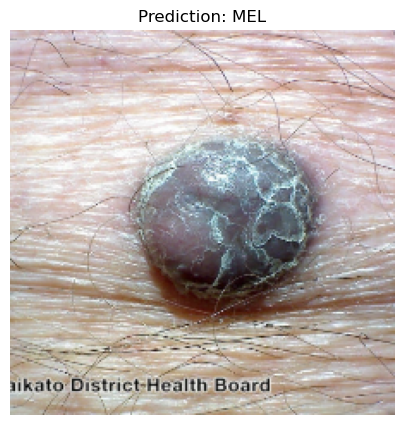

In [4]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

# =========================
# CONFIG
# =========================
IMAGE_PATH = r"melanoma2.webp"   # replace this
MODEL_PATH = r"pipeline_output\models\best_model.keras"

CLASS_NAMES = ["NV", "MEL", "BCC"]
TARGET_SIZE = 224

# =========================
# LOAD MODEL
# =========================
model = keras.models.load_model(MODEL_PATH)

# =========================
# PREPROCESS FUNCTION
# Matches your Section 11 inference path
# =========================
def preprocess_local_image(image_path, target_size=TARGET_SIZE):
    raw_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_image(raw_bytes, channels=3, expand_animations=False)

    shape = tf.shape(image)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)
    target_f = tf.cast(target_size, tf.float32)

    scale = target_f / tf.minimum(h, w)
    new_h = tf.cast(tf.math.ceil(h * scale), tf.int32)
    new_w = tf.cast(tf.math.ceil(w * scale), tf.int32)

    image = tf.image.resize(image, [new_h, new_w], method="bilinear")
    image = tf.image.resize_with_crop_or_pad(image, target_size, target_size)
    image = tf.cast(image, tf.float32)

    # Keep a displayable version
    display_image = tf.cast(image, tf.uint8)

    # EfficientNet preprocessing
    model_input = tf.keras.applications.efficientnet.preprocess_input(image)

    return display_image, model_input

# =========================
# RUN INFERENCE
# =========================
display_image, model_input = preprocess_local_image(IMAGE_PATH)
batch = tf.expand_dims(model_input, axis=0)

preds = model.predict(batch, verbose=0)[0]
pred_idx = int(np.argmax(preds))
pred_label = CLASS_NAMES[pred_idx]

print("Image path:", IMAGE_PATH)
print("Predicted class:", pred_label)
print("Class probabilities:")
for cls, p in zip(CLASS_NAMES, preds):
    print(f"  {cls}: {p:.4f}")

# =========================
# SHOW IMAGE
# =========================
plt.figure(figsize=(5, 5))
plt.imshow(display_image.numpy())
plt.title(f"Prediction: {pred_label}")
plt.axis("off")
plt.show()